In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import libs.CameraProcessor as cp

### Funciones

In [2]:
def build_dataset(csv_dir, img_dir, distances, angles, img_names) -> pd.DataFrame:
    """
    Construye un único DataFrame a partir de:
    - CSVs del microcontrolador
    - imágenes procesadas
    - distancias y ángulos calculados
    """
    records = []

    # Normalizar nombres de imágenes
    normalized_img_names = []
    for name in img_names:
        bn = os.path.basename(name).lower()
        normalized_img_names.append(bn)

    # Dictionary: {file_name : idx}
    img_map = {normalized_img_names[i]: i for i in range(len(img_names))}

    # Ordenar CSVs numéricamente
    csv_files = sorted(
        [f for f in os.listdir(csv_dir) if f.endswith(".csv")],
        key=lambda x: int(x.replace(".csv", ""))
    )

    for csv_file in csv_files:
        csv_id = int(csv_file.replace(".csv", ""))
        in_path = os.path.join(csv_dir, csv_file)

        # Leer CSV del micro
        df_csv = pd.read_csv(in_path)
        if df_csv.empty:
            print(f"[WARN] {csv_file} vacío.")
            continue

        # Parsear vectores del micro
        row = df_csv.iloc[0].to_dict()
        for col in ["angulo", "ultrasonico", "infrarrojo", "kalman"]:   #Columnas que deben pasarse de string a número
            if col in row:
                row[col] = parse_vector(row[col])

        # Buscar imagen asociada
        found_match = False

        for ext in [".jpeg", ".jpg", ".png"]:
            expected_img = f"{csv_id}{ext}".lower()

            if expected_img in img_map:
                idx = img_map[expected_img]

                row["angulos_mapa"] = angles[idx]
                row["distancias_mapa"] = distances[idx]
                row["image_path"] = os.path.join(img_dir, expected_img)
                print(f"[OK] {csv_file} + {expected_img}")
                found_match = True
                break

        # No se encontró imagen
        if not found_match:
            row["angulos_mapa"] = None
            row["distancias_mapa"] = None
            row["image_path"] = None
            print(f"[WARN] {csv_file} sin imagen asociada.")

        records.append(row)

    # Crear DataFrame final
    dataset = pd.DataFrame(records)
    return dataset

def parse_vector(value):
    """
    Convierte un string JSON tipo:
        "[1, 2, 3]"
    a una lista Python.

    Retorna None si falla.
    """
    if pd.isna(value) or value == "":   # Empty value
        return None
    if isinstance(value, list):         # Already list
        return value

    try:
        return json.loads(value)
    except (json.JSONDecodeError, TypeError):
        return None
    
def plot_polar(angles_deg, values, title=None, ax:plt.Axes=None, 
               threshold=None, threshold_color="red", **plot_kwargs):
    if ax is None:
        fig = plt.figure(figsize=(6,6))
        ax = fig.add_subplot(111, projection="polar")
    else:
        fig = ax.figure

    angles_rad = np.deg2rad(angles_deg)
    ax.plot(angles_rad, values, **plot_kwargs)

    # Limite
    if threshold is not None:
        full_circle = np.linspace(0, 2*np.pi, 400)
        r_max = max(max(values), threshold * 1.2)
        ax.fill_between(full_circle, threshold, r_max, color=threshold_color, alpha=0.2)
        ax.plot(full_circle, np.full_like(full_circle, threshold), color=threshold_color, linestyle="--", linewidth=1.5)
        ax.set_ylim(0, threshold * 1.1)
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)

    if title:
        ax.set_title(title)

    ax.grid(True)
    return fig, ax

def plot_all_scans(df: pd.DataFrame, idx, mode="side", threshold = 500):
    """
    mode="side": 3 subplots polares, lado a lado
    mode="overlay": 3 curvas superpuestas en 1 solo polar
    """

    row = df.iloc[idx]
    ang = row["angulo"]
    us  = row["ultrasonico"]
    ir  = row["infrarrojo"]
    ang_map = row.get("angulos_mapa")
    dist_map = row.get("distancias_mapa")
    
    scan_id = row.get("id", idx)

    # --- MODO SUBPLOTS LATERALES ---
    if mode == "side":
        fig = plt.figure(figsize=(18,6))
        
        # Ultrasonido
        ax1 = fig.add_subplot(131, projection="polar")
        plot_polar(ang, us, title="Ultrasonido", ax=ax1, threshold=threshold)

        # Infrarrojo
        ax2 = fig.add_subplot(132, projection="polar")
        plot_polar(ang, ir, title="Infrarrojo", ax=ax2, threshold=threshold)

        # Imagen procesada
        ax3 = fig.add_subplot(133, projection="polar")
        plot_polar(ang_map, dist_map, title="Foto procesada", ax=ax3, threshold=threshold)

        fig.suptitle(f"Medición ID {scan_id}", fontsize=14)
        plt.tight_layout()
        plt.show()
        return fig

    # --- MODO SUPERPUESTO ---
    elif mode == "overlay":
        fig = plt.figure(figsize=(7,7))
        ax = fig.add_subplot(111, projection="polar")

        plot_polar(ang, us,  ax=ax, label="Ultrasonido", threshold=threshold)
        plot_polar(ang, ir,  ax=ax, label="Infrarrojo", threshold=threshold)
        plot_polar(ang_map, dist_map, ax=ax, label="Distancia mapa", threshold=threshold)

        ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
        ax.set_title(f"Medición ID {scan_id} — Comparación")

        plt.show()
        return fig

    else:
        raise ValueError('mode debe ser "side" o "overlay"')
    

# Build Dataset Completo

In [15]:
# Carpeta de entrada
path_img_raw_0 = r"E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\25_12_09\images_raw_corregidas"       # Imágenes
path_img_raw_1 = r"E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_03_04\images_raw"       # Imágenes
path_img_raw_2 = r"E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_03\images_raw"       # Imágenes
path_img_raw_3 = r"E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_11\images_raw"       # Imágenes
path_img_raw = [path_img_raw_0, path_img_raw_1, path_img_raw_2, path_img_raw_3]

path_sensors_csv_0 = r"E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\25_12_09\csv_sensores" # CSV microcontrolador
path_sensors_csv_1 = r"E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_03_04\csv_sensores" # CSV microcontrolador
path_sensors_csv_2 = r"E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_03\csv_sensores" # CSV microcontrolador
path_sensors_csv_3 = r"E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_11\csv_sensores" # CSV microcontrolador
path_sensors_csv = [path_sensors_csv_0, path_sensors_csv_1, path_sensors_csv_2, path_sensors_csv_3]

# Archivo de salida
path_ds_0 = r"E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\25_12_09\dataset_25_12_09_corr.parquet"
path_ds_1 = r"E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_03_04\dataset_26_03_04.parquet"
path_ds_2 = r"E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_03\dataset_26_05_03.parquet"
path_ds_3 = r"E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_11\dataset_26_05_11.parquet"
path_ds_out = [path_ds_0, path_ds_1, path_ds_2, path_ds_3]
path_ds_merged = r"E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\merged\dataset_corr.parquet"

# Archivo de calibracion de la cámara
file_calib_matrix_0 = r"E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\25_12_09\calib_matrix_celu_agus.npz"
file_calib_matrix_1 = r"E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_03_04\calib_matrix.npz"
file_calib_matrix_2 = r"E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_03\calib_matrix.npz"
file_calib_matrix_3 = r"E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_11\calib_matrix.npz"
file_calib_matrix = [file_calib_matrix_0, file_calib_matrix_1, file_calib_matrix_2, file_calib_matrix_3]

# Mapa y dimensiones
corner_ids = [15,15,15,15]  # AruCo
map_size = [(680, 620), (800, 800), (800, 800), (800, 800)]       # En mm
pixels_per_mm = 2           # Resolution

# Angulo de paso entre mediciones
angle_step = 3

# Filtro de color para el mapa
color_filter = ((80, 120, 50), (160, 255, 255)) # Corresponde a AZUL

# Inf. value
max_value = None

In [16]:
cam = cp.CameraProcessor()
cam.loadCalibMatrix(file_calib_matrix[0])

# Calibración de fotos.
distances, angles, img_names = cam.processDistances(path_img_raw[0], corner_ids, color_filter, 
													map_size[0], pixels_per_mm, angle_step=angle_step, 
													max_value=max_value)
# Unión de valores y creación del dataset
df = build_dataset(path_sensors_csv[0], path_img_raw[0], distances, angles, img_names)
df.to_parquet(path_ds_out[0])

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\25_12_09\images_raw_corregidas\1.jpg
Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\25_12_09\images_raw_corregidas\10.jpg
Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\25_12_09\images_raw_corregidas\100.jpg
Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\25_12_09\images_raw_corregidas\101.jpg
Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\25_12_09\images_raw_corregidas\102.jpg
Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\25_12_09\images_raw_corregidas\103.jpg
Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\25_12_09\images_raw_corregidas\104.jpg
Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\25_12_09\images_raw_corregidas\105.jpg
Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Datase

In [ ]:
cam = cp.CameraProcessor()
cam.loadCalibMatrix(file_calib_matrix[1])

# Calibración de fotos.
distances, angles, img_names = cam.processDistances(path_img_raw[1], corner_ids, color_filter, 
													map_size[1], pixels_per_mm, angle_step=angle_step, 
													max_value=max_value)
# Unión de valores y creación del dataset
df = build_dataset(path_sensors_csv[1], path_img_raw[1], distances, angles, img_names)
df.to_parquet(path_ds_out[1])

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_03_04\images_raw\1.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_03_04\images_raw\10.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_03_04\images_raw\11.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_03_04\images_raw\12.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_03_04\images_raw\13.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_03_04\images_raw\14.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_03_04\images_raw\15.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_03_04\images_raw\16.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_03_04\images_raw\17.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por

In [ ]:
cam = cp.CameraProcessor()
cam.loadCalibMatrix(file_calib_matrix[2])

# Calibración de fotos.
distances, angles, img_names = cam.processDistances(path_img_raw[2], corner_ids, color_filter, 
													map_size[2], pixels_per_mm, angle_step=angle_step, 
													max_value=max_value)
# Unión de valores y creación del dataset
df = build_dataset(path_sensors_csv[2], path_img_raw[2], distances, angles, img_names)
df.to_parquet(path_ds_out[2])

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_03\images_raw\1.jpg
Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_03\images_raw\10.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_03\images_raw\100.jpg
Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_03\images_raw\101.jpg
Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_03\images_raw\102.jpg
Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_03\images_raw\103.jpg
Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_03\images_raw\11.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_03\images_raw\12.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_03\images_raw\13.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-

In [ ]:
cam = cp.CameraProcessor()
cam.loadCalibMatrix(file_calib_matrix[3])

# Calibración de fotos.
distances, angles, img_names = cam.processDistances(path_img_raw[3], corner_ids, color_filter, 
													map_size[3], pixels_per_mm, angle_step=angle_step, 
													max_value=max_value)
# Unión de valores y creación del dataset
df = build_dataset(path_sensors_csv[3], path_img_raw[3], distances, angles, img_names)
df.to_parquet(path_ds_out[3])

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_11\images_raw\1.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_11\images_raw\10.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_11\images_raw\11.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_11\images_raw\12.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_11\images_raw\13.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_11\images_raw\14.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_11\images_raw\15.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_11\images_raw\16.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_11\images_raw\17.jpg

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por

In [17]:
dfs = [pd.read_parquet(path) for path in path_ds_out]
merged_df = pd.concat(dfs, ignore_index=True)

merged_df.to_parquet(path_ds_merged)

In [18]:
merged_df = pd.read_parquet(path_ds_merged)
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               418 non-null    int64  
 1   fecha            418 non-null    str    
 2   imagen_path      0 non-null      float64
 3   angulo           418 non-null    object 
 4   ultrasonico      418 non-null    object 
 5   infrarrojo       418 non-null    object 
 6   kalman           418 non-null    object 
 7   angulos_mapa     389 non-null    object 
 8   distancias_mapa  389 non-null    object 
 9   image_path       389 non-null    str    
dtypes: float64(1), int64(1), object(6), str(2)
memory usage: 75.3+ KB


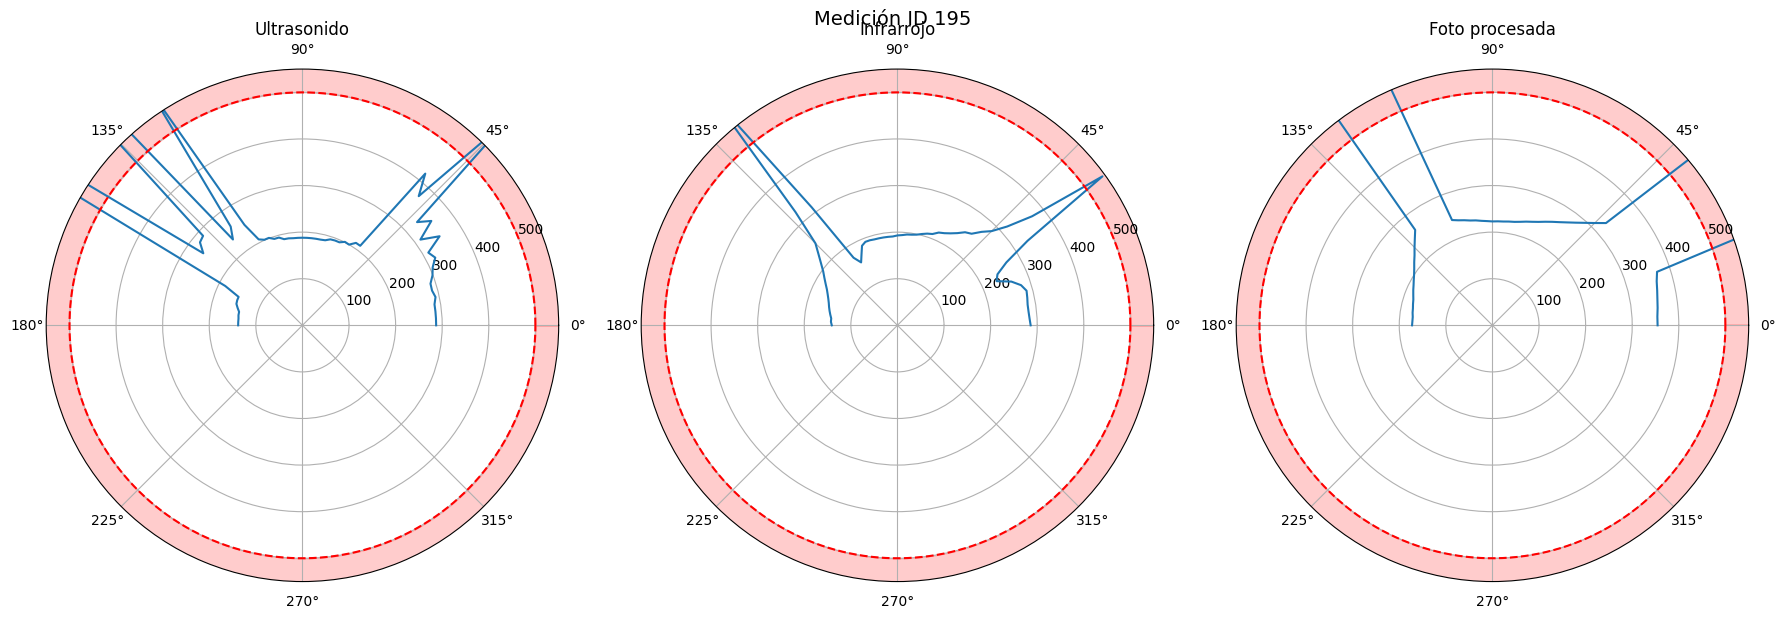

E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\25_12_09\images_raw\195.jpg


In [16]:
idx = 194
plot_all_scans(merged_df, idx)
print(merged_df.image_path[idx])

# Creacion del Dataset

Se transforma la información original en un dataset unificado.
La información original es:
* Una carpeta con .csv con las mediciones del microcontrolador.
* Una carpeta con la foto correspondiente de cada medición del microcontrolador.

### Calibración Previa

No realizar si ya se posee el archivo de calibracion

### Build del Dataset

Union de los datos del csv entregado por el microcontrolador y las fotos procesadas. Importante. Tanto los csv como las imágenes deben tener el mismo nombre. Ej: 1.csv -> 1.jpeg

### Merge de múltiples Datasets

En caso de haber realizado la acción anterior múltiples veces, se recomienda unir todos los parquet en un único archivo.
Esto se desará de los ID originales pero las fotos podrán seguir siendo rastreadas con el campo img_dir dentro del dataset.